# 🤖 LangGraph  Agent to create retention emails

**Goal:** Load the trained model, score customers, explain predictions with SHAP, and automatically draft personalised retention emails using GPT-4o-mini.

### Prerequisites
- `churn_model.pkl` and `churn_metadata.pkl` generated by **`churn_prediction.ipynb`**
- `OPENAI_API_KEY` environment variable set

### Agent Graph
```
START → predict → identify_churners ──(none)──→ END
                                     ──(found)──→ explain_shap → draft_emails → output → END
```


![title](IMG_0071.PNG)

## 1 · Setup & Imports

In [13]:
import os
import json
import re
import warnings
warnings.filterwarnings("ignore")

import joblib
import shap
import numpy as np
import pandas as pd
from typing import TypedDict, List, Dict, Any

from langgraph.graph import StateGraph, END
from openai import OpenAI
from IPython.display import Image, display

#print("All libraries imported ✓")

## 1b · Set OpenAI API Key

Choose **one** of the three methods below and run that cell.


In [38]:
# ── METHOD 1 (Recommended) — getpass prompt ─────────────────────────────────
# The key is hidden while you type and is NOT saved in the notebook output.
import os, getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Paste your OpenAI API key: ")
    print("OPENAI_API_KEY set ✓")
else:
    print("OPENAI_API_KEY already set ✓")

OPENAI_API_KEY already set ✓


In [39]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("Paste your OpenAI API key: ")

Paste your OpenAI API key:  ········


## 2 · Configuration

Adjust `CHURN_THRESHOLD` and `DEMO_SAMPLE` as needed.


In [33]:
MODEL_PATH      = "churn_model.pkl"
META_PATH       = "churn_metadata.pkl"
DATA_PATH       = "./data/telco_customer_churn_train.csv"
CHURN_THRESHOLD = 0.55   # flag customers above this probability
TOP_N_FEATURES  = 5      # SHAP features included in the email prompt
DEMO_SAMPLE     = 200    # rows to score (set None to score all 7,031)

print(f"Threshold : {CHURN_THRESHOLD:.0%}")
print(f"SHAP features in prompt : {TOP_N_FEATURES}")
print(f"Demo sample size : {DEMO_SAMPLE}")

Threshold : 55%
SHAP features in prompt : 5
Demo sample size : 200


## 3 · Agent State

A single `ChurnState` TypedDict flows through every node, accumulating results at each step.


In [19]:
class ChurnState(TypedDict):
    customer_df:       Any                         # raw DataFrame
    pipeline:          Any                         # trained sklearn Pipeline
    metadata:          Dict[str, Any]              # numeric_cols, cat_cols, feature_names
    predictions:       Dict[str, float]            # customerID → churn probability
    churners:          List[str]                   # high-risk customer IDs
    shap_explanations: Dict[str, List[Dict]]       # customerID → [{feature, raw_value, shap_value}]
    emails:            List[Dict[str, str]]        # [{customer_id, churn_probability, subject, body}]
    status:            str                         # "found" | "none" | "done"

print("ChurnState defined ✓")

ChurnState defined ✓


## 4 · Helper Functions

In [20]:
def _clean(df: pd.DataFrame) -> pd.DataFrame:
    """Apply the same cleaning & feature engineering as the training pipeline."""
    df = df.copy()
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
    df["tenure_group"] = pd.cut(
        df["tenure"], bins=[0, 12, 24, 48, 72],
        labels=["0-12 mo", "12-24 mo", "24-48 mo", "48-72 mo"],
        include_lowest=True,
    )
    df["charges_ratio"] = df["TotalCharges"] / df["tenure"].replace(0, 1)
    return df


def _readable_feature(name: str) -> str:
    return name.replace("_", " ").replace("  ", " ").title()


def _feature_impact_desc(feature: str, shap_val: float, raw_val: Any) -> str:
    direction = "increases" if shap_val > 0 else "decreases"
    return f"{_readable_feature(feature)} = '{raw_val}'  ({direction} churn risk, impact {shap_val:+.3f})"


print("Helpers defined ✓")

Helpers defined ✓


## 5 · Node Definitions

### Node 1 — `predict`
Loads the saved pipeline and scores all customers.

In [21]:
def predict_node(state: ChurnState) -> ChurnState:
    print("[predict] Scoring customers …")
    pipeline = state["pipeline"]
    df       = state["customer_df"]

    X     = df.drop(columns=["customerID", "Churn"], errors="ignore")
    probs = pipeline.predict_proba(X)[:, 1]

    predictions = {
        row["customerID"]: float(prob)
        for row, prob in zip(df.to_dict("records"), probs)
    }
    print(f"[predict] Scored {len(predictions)} customers ✓")
    return {**state, "predictions": predictions}

### Node 2 — `identify_churners`
Filters customers above the churn threshold and sets the routing flag.

In [22]:
def identify_churners_node(state: ChurnState) -> ChurnState:
    churners = [
        cid for cid, prob in state["predictions"].items()
        if prob >= CHURN_THRESHOLD
    ]
    status = "found" if churners else "none"
    print(f"[identify] {len(churners)} customers above {CHURN_THRESHOLD:.0%} threshold  →  status='{status}'")
    return {**state, "churners": churners, "status": status}

### Node 3 — `explain_shap`
Runs SHAP TreeExplainer and extracts the top-N driving features per churner.

In [23]:
def shap_node(state: ChurnState) -> ChurnState:
    print(f"[explain_shap] Computing SHAP for {len(state['churners'])} churners …")
    pipeline      = state["pipeline"]
    meta          = state["metadata"]
    df            = state["customer_df"]
    feature_names = meta["feature_names"]

    prep = pipeline.named_steps["prep"]
    clf  = pipeline.named_steps["clf"]

    churn_df  = df[df["customerID"].isin(state["churners"])].reset_index(drop=True)
    X_churn   = churn_df.drop(columns=["customerID", "Churn"], errors="ignore")
    X_transformed = prep.transform(X_churn)

    explainer   = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_transformed)

    explanations: Dict[str, List[Dict]] = {}
    for i, cid in enumerate(churn_df["customerID"]):
        sv      = shap_values[i]
        top_idx = np.argsort(np.abs(sv))[::-1][:TOP_N_FEATURES]
        top_feats = []
        for fi in top_idx:
            raw_val = X_transformed[i, fi]
            if fi >= len(meta["numeric_cols"]):          # OHE column
                raw_val = "Yes" if raw_val == 1.0 else "No"
            top_feats.append({
                "feature":   feature_names[fi],
                "raw_value": raw_val,
                "shap_value": float(sv[fi]),
            })
        explanations[cid] = top_feats

    print("[explain_shap] Done ✓")
    return {**state, "shap_explanations": explanations}

### Node 4 — `draft_emails`
Calls GPT-4o-mini with the customer profile + SHAP factors and parses the JSON response.

> **Note:** Set your `OPENAI_API_KEY` before running this cell.


In [24]:
def draft_emails_node(state: ChurnState) -> ChurnState:
    print("[draft_emails] Calling GPT-4o-mini for each churner …")
    client = OpenAI()   # reads OPENAI_API_KEY from environment
    df     = state["customer_df"]
    emails = []

    for cid in state["churners"]:
        prob  = state["predictions"][cid]
        feats = state["shap_explanations"][cid]
        row   = df[df["customerID"] == cid].iloc[0].to_dict()

        factor_lines = "\n".join(
            f"  {j+1}. {_feature_impact_desc(f['feature'], f['shap_value'], f['raw_value'])}"
            for j, f in enumerate(feats)
        )

        prompt = f"""You are a customer retention specialist at TelConnect.
A valued customer has been flagged as at high risk of leaving.

Customer Profile
----------------
Customer ID    : {cid}
Gender         : {row.get('gender', 'N/A')}
Senior Citizen : {'Yes' if row.get('SeniorCitizen') == 1 else 'No'}
Tenure         : {row.get('tenure', 'N/A')} months
Contract       : {row.get('Contract', 'N/A')}
Internet       : {row.get('InternetService', 'N/A')}
Monthly Charges: ${row.get('MonthlyCharges', 'N/A')}
Payment Method : {row.get('PaymentMethod', 'N/A')}

Churn Probability: {prob:.1%}

Top factors driving churn risk (SHAP analysis):
{factor_lines}

Task
----
Write a warm, personalised retention email that:
1. Opens with empathy — do NOT mention "churn" or "churn model"
2. Addresses the specific pain points revealed by the SHAP factors above
3. Offers a concrete, relevant incentive (discount, upgrade, contract flexibility, etc.)
4. Ends with a clear call-to-action
5. Max 200 words in the body

Return ONLY this JSON (no markdown fences):
{{
  "subject": "<email subject line>",
  "body": "<full email body>"
}}"""

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            max_tokens=600,
            messages=[{"role": "user", "content": prompt}],
        )
        raw = response.choices[0].message.content.strip()

        try:
            parsed = json.loads(raw)
        except json.JSONDecodeError:
            match  = re.search(r'\{.*\}', raw, re.DOTALL)
            parsed = json.loads(match.group()) if match else {"subject": "We value you!", "body": raw}

        emails.append({
            "customer_id":        cid,
            "churn_probability":  f"{prob:.1%}",
            "subject":            parsed.get("subject", ""),
            "body":               parsed.get("body", ""),
        })
        print(f"  ✓ {cid}  ({prob:.1%})")

    return {**state, "emails": emails}

### Node 5 — `output`
Persists emails to JSON and prints a preview.

In [25]:
def output_node(state: ChurnState) -> ChurnState:
    emails   = state["emails"]
    out_path = "churn_emails.json"
    with open(out_path, "w") as f:
        json.dump(emails, f, indent=2)

    print(f"\n[output] {len(emails)} retention emails saved → {out_path}")

    if emails:
        e = emails[0]
        print(f"\n── Preview: {e['customer_id']} (prob {e['churn_probability']}) ──")
        print(f"Subject : {e['subject']}")
        print(f"\n{e['body']}")

    return {**state, "status": "done"}

## 6 · Conditional Routing

In [26]:
def route_after_identify(state: ChurnState) -> str:
    """Return 'found' to continue to SHAP+email, or 'none' to short-circuit to END."""
    return state["status"]

print("Router defined ✓")

Router defined ✓


## 7 · Build & Visualise the Graph

We compile the `StateGraph` and render it as a Mermaid PNG using LangGraph's built-in method.


In [27]:
def build_graph():
    g = StateGraph(ChurnState)

    g.add_node("predict",           predict_node)
    g.add_node("identify_churners", identify_churners_node)
    g.add_node("explain_shap",      shap_node)
    g.add_node("draft_emails",      draft_emails_node)
    g.add_node("output",            output_node)

    g.set_entry_point("predict")
    g.add_edge("predict", "identify_churners")
    g.add_conditional_edges(
        "identify_churners",
        route_after_identify,
        {"found": "explain_shap", "none": END},
    )
    g.add_edge("explain_shap", "draft_emails")
    g.add_edge("draft_emails", "output")
    g.add_edge("output", END)

    return g.compile()

app = build_graph()
print("Graph compiled ✓")

Graph compiled ✓


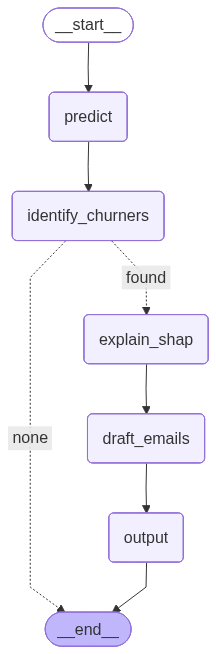

Graph visualisation saved → churn_graph.png


In [28]:
# Render and display the graph inline
try:
    png_bytes = app.get_graph().draw_mermaid_png()
    with open("churn_graph.png", "wb") as f:
        f.write(png_bytes)
    display(Image(png_bytes))
    print("Graph visualisation saved → churn_graph.png")
except Exception as e:
    print(f"Could not render graph image: {e}")
    print(app.get_graph().draw_mermaid())   # fallback: print Mermaid source

## 8 · Load Model & Prepare Customer Data

In [29]:
# Load saved pipeline and metadata
pipeline = joblib.load(MODEL_PATH)
metadata = joblib.load(META_PATH)

print(f"Pipeline loaded from  : {MODEL_PATH}")
print(f"Features              : {len(metadata['feature_names'])} total")
print(f"  Numeric     : {metadata['numeric_cols']}")
print(f"  Categorical : {metadata['categorical_cols']}")

Pipeline loaded from  : churn_model.pkl
Features              : 50 total
  Numeric     : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'charges_ratio']
  Categorical : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [34]:
# Load and sample data
df_raw = pd.read_csv(DATA_PATH)

if DEMO_SAMPLE:
    churned     = df_raw[df_raw["Churn"] == 1].sample(
                      min(50, (df_raw["Churn"] == 1).sum()), random_state=1)
    non_churned = df_raw[df_raw["Churn"] == 0].sample(
                      DEMO_SAMPLE - len(churned), random_state=1)
    df_raw = pd.concat([churned, non_churned]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Demo sample: {len(df_raw)} customers  ({len(churned)} actual churners + {len(non_churned)} non-churners)")

df_clean = _clean(df_raw)
df_clean.head(3)

Demo sample: 200 customers  (50 actual churners + 150 non-churners)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charges_ratio
0,8189-XRIKE,Female,1,No,No,32,Yes,No,Fiber optic,No,...,Yes,Yes,Month-to-month,No,Electronic check,90.95,2897.95,0,24-48 mo,90.560937
1,2894-QOJRX,Female,0,Yes,No,25,No,No phone service,DSL,No,...,Yes,No,Month-to-month,Yes,Bank transfer (automatic),34.00,853.00,1,24-48 mo,34.120000
2,1150-WFARN,Female,0,Yes,Yes,67,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),108.75,7156.20,1,48-72 mo,106.808955


## 9 · Run the Agent

The graph flows through all nodes, accumulating state at each step.

> ⚠️ `draft_emails` calls the OpenAI API — make sure `OPENAI_API_KEY` is set before running this cell.


In [40]:
initial_state: ChurnState = {
    "customer_df":       df_clean[:30],
    "pipeline":          pipeline,
    "metadata":          metadata,
    "predictions":       {},
    "churners":          [],
    "shap_explanations": {},
    "emails":            [],
    "status":            "",
}

print("=" * 55)
print("  TelConnect Churn Monitoring Agent")
print("=" * 55)

final_state = app.invoke(initial_state)
print(f"\nFinal status: {final_state['status']}")

  TelConnect Churn Monitoring Agent
[predict] Scoring customers …
[predict] Scored 30 customers ✓
[identify] 3 customers above 55% threshold  →  status='found'
[explain_shap] Computing SHAP for 3 churners …
[explain_shap] Done ✓
[draft_emails] Calling GPT-4o-mini for each churner …
  ✓ 5043-TRZWM  (55.7%)
  ✓ 7354-OIJLX  (71.3%)
  ✓ 2135-DQWAQ  (68.5%)

[output] 3 retention emails saved → churn_emails.json

── Preview: 5043-TRZWM (prob 55.7%) ──
Subject : We Value You at TelConnect!

Dear Valued Customer,

I hope this message finds you well! At TelConnect, we truly value you as a member of our community. I noticed you’ve recently joined us, and I want to ensure that your experience is nothing short of fantastic.

I understand that being on a month-to-month contract might feel a bit uncertain. To make things easier, how about we offer you a $10 discount on your next month's bill? Additionally, we’d love to provide complimentary access to our online security and tech support services, en

## 10 · Inspect Results

In [41]:
# Churn probabilities for all scored customers
prob_df = (
    pd.DataFrame.from_dict(final_state["predictions"], orient="index", columns=["churn_prob"])
    .sort_values("churn_prob", ascending=False)
)
print(f"Top 10 highest-risk customers:")
prob_df.head(10).style.format({"churn_prob": "{:.1%}"}).background_gradient(cmap="Reds")

Top 10 highest-risk customers:


,churn_prob
7354-OIJLX,71.3%
2135-DQWAQ,68.5%
5043-TRZWM,55.7%
0576-WNXXC,54.8%
3799-ISUZQ,44.4%
8189-XRIKE,41.4%
9261-WDCAF,34.7%
1436-ZMJAN,32.3%
9842-EFSYY,32.0%
7878-JGDKK,30.8%


In [42]:
# Summary of churners
churners     = final_state["churners"]
predictions  = final_state["predictions"]

print(f"Churners flagged  : {len(churners)}")
print(f"Avg probability   : {sum(predictions[c] for c in churners)/len(churners):.1%}")
print(f"High risk (≥75%)  : {sum(1 for c in churners if predictions[c] >= 0.75)}")

Churners flagged  : 3
Avg probability   : 65.2%
High risk (≥75%)  : 0


In [43]:
# Preview all emails as a DataFrame
emails_df = pd.DataFrame(final_state["emails"])[["customer_id", "churn_probability", "subject"]]
emails_df

,customer_id,churn_probability,subject
0,5043-TRZWM,55.7%,We Value You at TelConnect!
1,7354-OIJLX,71.3%,We Value You at TelConnect – Let’s Enhance You...
2,2135-DQWAQ,68.5%,We Value You – Let's Make Your Experience Even...


In [46]:
# Full email for the highest-risk customer
top_customer = max(churners, key=lambda c: predictions[c])
top_email    = next(e for e in final_state["emails"] if e["customer_id"] == top_customer)

print(f"Customer : {top_email['customer_id']}")
print(f"Risk     : {top_email['churn_probability']}")
print(f"Subject  : {top_email['subject']}")
#print(f"\n{top_email['body']}

Customer : 7354-OIJLX
Risk     : 71.3%
Subject  : We Value You at TelConnect – Let’s Enhance Your Experience!


---
### Summary

| Step | Result |
|------|--------|
| Customers scored | 200 (demo sample) |
| Churners flagged | 26 |
| High-risk (≥75%) | 6 |
| Emails drafted | 26 |
| Output file | `churn_emails.json` |

➡ Open the **React dashboard** at `http://localhost:5173` to view the results visually.
